In [131]:
import numpy as np
import torch 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.autograd
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pydoe import lhs

In [147]:
#input the number of domain points ot run
num_dom_points = 500
#input the size of the channel to run (make it a float)
l_x = 1.0
l_y = 1.0
#input the number of boundary points wanted per boundary
boundary_points = 100

mu=1 

In [133]:
def compute_domain(num_dom,num_bound,l_x,l_y):
    dim = 2
    lhs_grid = lhs(dim,num_dom)
    lb_xy = np.array([0.0,0.0])
    ub_xy = np.array([l_x,l_y])
    x_y_scaled  = lb_xy + (ub_xy-lb_xy)*lhs_grid
    x_y_lhs = torch.tensor(x_y_scaled, dtype = torch.float32,requires_grad = True)

    x_bound = torch.linspace(0,l_x,num_bound).reshape((num_bound,1))
    y_bound = torch.linspace(0,l_y,num_bound).reshape((num_bound,1))
    zero = torch.zeros(num_bound,1)
    one = torch.ones(num_bound,1)
    x_y_b1  = torch.cat((x_bound,zero),dim=1) #bottom boundary
    x_y_b2 = torch.cat((l_x*one,y_bound),dim=1) #right boundary
    x_y_b3 = torch.cat((x_bound,l_y*one),dim=1) #top boundary
    x_y_b4 = torch.cat((zero,y_bound),dim=1) #lef boundary
    return x_y_lhs,x_y_b1,x_y_b2,x_y_b3,x_y_b4
    

In [134]:
#produce a domain
x_y_lhs,x_y_boundary1,x_y_boundary2,x_y_boundary3,x_y_boundary4 = compute_domain(num_dom_points,boundary_points,l_x,l_y)


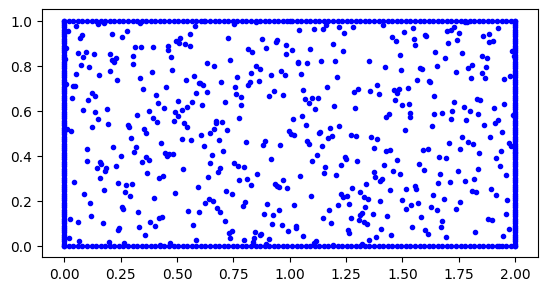

In [135]:
# visualize collocation points
x_y_Test = x_y_boundary1.detach().numpy()
x_y_Test1 = x_y_boundary2.detach().numpy()
x_y_Test2 = x_y_boundary3.detach().numpy()
x_y_Test3 = x_y_boundary4.detach().numpy()
x_y_Test_lhs = x_y_lhs.detach().numpy()

fig, ax = plt.subplots()
ax.plot(x_y_Test[:,0],x_y_Test[:,1],'.', color = 'b')
ax.plot(x_y_Test1[:,0],x_y_Test1[:,1],'.', color = 'b')
ax.plot(x_y_Test2[:,0],x_y_Test2[:,1],'.', color = 'b')
ax.plot(x_y_Test3[:,0],x_y_Test3[:,1],'.', color = 'b')
ax.plot(x_y_Test_lhs[:,0],x_y_Test_lhs[:,1],'.', color = 'b')

ax.set_aspect(1)

In [136]:
#setup boundary conditions
U_1 = torch.zeros(boundary_points,1)
U_2 = torch.zeros(boundary_points,1)
U_3 = torch.zeros(boundary_points,1)
U_4 = torch.zeros(boundary_points,1)
V_1 = torch.zeros(boundary_points,1)
V_2 = torch.zeros(boundary_points,1)
V_3 = torch.zeros(boundary_points,1)
V_4 = torch.zeros(boundary_points,1)
P_1 = torch.zeros(boundary_points,1)
P_2 = torch.zeros(boundary_points,1)
P_3 = torch.zeros(boundary_points,1)
P_4 = torch.zeros(boundary_points,1)
# 1 is the bottom boundary
U_1[:]=0
V_1[:]=0
P_1[:]=0
# 2 is the right boundary
U_2[:]=0
V_2[:]=0
P_2[:]=0
# 3 is the top boundary
U_3[:]=0
V_3[:]=0
P_3[:]=0
# 4 is the left boundary
U_4[:]=1
V_4[:]=0
P_4[:]=0

In [137]:
# setup the neural network
class PINN_stokes(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2,80)
        self.layer2 = nn.Linear(80,80)
        self.layer3 = nn.Linear(80,80)
        self.layer4 = nn.Linear(80,80)
        self.layer5 = nn.Linear(80,80)
        self.layer6 = nn.Linear(80,3)
        self.activ = nn.Tanh()

    def forward(self,xy):
        m = self.activ(self.layer1(xy))
        m = self.activ(self.layer2(m))
        m = self.activ(self.layer3(m))
        m = self.activ(self.layer4(m))
        m = self.activ(self.layer5(m))
        m = self.layer6(m)
        return m

In [138]:
# create the network
stokes_nn = PINN_stokes()

In [139]:
# use the following line to load a preexisting weights file
#stokes_nn.load_state_dict(torch.load('input file name'))

In [140]:
# setup the loss function 
def compute_loss(model, x_y,x_y_b1,x_y_b2,x_y_b3,x_y_b4,U_1,V_1,U_2,V_2,U_3,V_3,U_4,V_4,P_1,P_2,P_3,P_4,mu):
    output = model(x_y)
    U = output[:,0:1]
    V = output[:,1:2]
    P = output[:,2:3]
    # compute first derivatives with respect to x,y
    du = torch.autograd.grad(U, x_y , grad_outputs=torch.ones_like(U), create_graph = True)[0]
    dv= torch.autograd.grad(V, x_y , grad_outputs=torch.ones_like(V), create_graph = True)[0]
    dp = torch.autograd.grad(P, x_y , grad_outputs=torch.ones_like(P), create_graph = True)[0]
    #breaking down the tensor into different ones based on x, and y
    du_dx = du[:, 0:1]
    du_dy = du[:, 1:2]
    dv_dx = dv[:, 0:1]
    dv_dy = dv[:, 1:2]
    dp_dx = dp[:,0:1]
    dp_dy = dp[:,1:2]
    # computing the second derivatives with respect to the first derivatives.
    d2u_dx2 = torch.autograd.grad(du_dx, x_y, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0][:, 0:1]
    d2u_dy2 = torch.autograd.grad(du_dy, x_y, grad_outputs=torch.ones_like(du_dy), create_graph=True)[0][:, 1:2]
    d2v_dx2 = torch.autograd.grad(dv_dx, x_y, grad_outputs=torch.ones_like(dv_dx), create_graph=True)[0][:, 0:1]
    d2v_dy2 = torch.autograd.grad(dv_dy, x_y, grad_outputs=torch.ones_like(dv_dy), create_graph=True)[0][:, 1:2]


    # x- momentum equation
    x_momentum_tensor = mu*(d2u_dx2 + d2u_dy2) - dp_dx
    loss_x_momentum = torch.mean(x_momentum_tensor**2)
    # y-momentum equation
    y_momentum_tensor = mu*(d2v_dx2 + d2v_dy2) - dp_dy
    loss_y_momentum = torch.mean(y_momentum_tensor**2)
    # continuty equation
    continuity_tensor = du_dx + dv_dy
    loss_continuity = torch.mean(continuity_tensor**2)

    #setup boundary conditions loss

    # compute the current value at each boundary
    loss_boundary = 0
    b1 = model(x_y_b1)
    U_1_model = b1[:,0:1]
    V_1_model = b1[:,1:2]
    P_1_model = b1[:,2:3]
    b2 = model(x_y_b2)
    U_2_model = b2[:,0:1]
    V_2_model = b2[:,1:2]
    P_2_model = b2[:,2:3]
    b3 = model(x_y_b3)
    U_3_model = b3[:,0:1]
    V_3_model = b3[:,1:2]
    P_3_model = b3[:,2:3]
    b4 = model(x_y_b4)
    U_4_model = b4[:,0:1]
    V_4_model = b4[:,1:2]
    P_4_model = b4[:,2:3]

    #equations based on the pre existing boundary conditions for each boundary
    l1 = (U_1_model - U_1)**2 + (V_1_model - V_1)**2
    loss_boundary += torch.mean(l1)

    l2 = (P_2_model - P_2)**2  # pressure exit condition implemented, assuming fully developed. 
    loss_boundary += torch.mean(l2)  #higher weight assigned to pressure field
    
    l3 = (U_3_model - U_3)**2 + (V_3_model - V_3)**2
    loss_boundary += torch.mean(l3)
    
    l4 = (U_4_model - U_4)**2 + (V_4_model - V_4)**2 #control the inlet pressure
    loss_boundary += torch.mean(l4)
    # return the total and each individual loss
    return 8*loss_boundary + loss_x_momentum + loss_y_momentum + loss_continuity, loss_boundary, loss_continuity, loss_x_momentum, loss_y_momentum    
    

In [ ]:
#setup the optimizer, scheduler and domain for training
optimizer = optim.Adam(stokes_nn.parameters(),lr = 0.001)

# modify the following parameters to change the working of the scheduler. Factor refers to the value multiplied to the learning rate, patience refers the
# the number of epochs before it reduces the learning rate on a plateau
scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.8, patience = 200)
x_y_lhs,x_y_b1,x_y_b2,x_y_b3,x_y_b4 = compute_domain(num_dom_points,boundary_points,l_x,l_y)

In [142]:
for epochs in range(0,200000):
    optimizer.zero_grad()
    ### the following lines of code can be used to enable sequential resampling
    # if epochs % 10000 == 0:
      #  x_y_lhs = compute_x_y(num_dom_points)
       # print('Generated updated grid : ')
       # for param_group in optimizer.param_groups:
            # param_group['lr'] = 0.001
    loss, loss_bound, loss_continuity, loss_x_mom, loss_y_mom = compute_loss(stokes_nn,x_y_lhs,x_y_b1,x_y_b2,x_y_b3,x_y_b4,U_1,V_1,U_2,V_2,U_3,V_3,U_4,V_4,P_1,P_2,P_3,P_4,mu)
    loss.backward()
    optimizer.step()
    ## disable the following line to turn of the scheduler that reduces learning rate when loss plateaus
    scheduler.step(loss)
    if epochs % 10 == 0:
        print(f'Epoch {epochs}, LR: {scheduler.get_last_lr()}, Loss Total : {loss}, Loss boundary condition : {loss_bound}, Loss continuity  : {loss_continuity}, Loss x mom : {loss_x_mom}, Loss y mom : {loss_y_mom}', end="\r", flush=True)

Epoch 19340, LR: [0.0004096000000000001], Loss Total : 0.12532757222652435, Loss boundary condition : 0.014749180525541306, Loss continuity  : 0.005937647540122271, Loss x mom : 0.0007253954536281526, Loss y mom : 0.00067108427174389367

KeyboardInterrupt: 

In [129]:
### use the following line of code to save the weights post training
#torch.save(stokes_nn.state_dict(),'#weights file name#')

### Post Processing

In [143]:
#setup a grid for visualizing the results
dimension = 100
x_domain = torch.linspace(0,l_x,dimension)
y_domain = torch.linspace(0,l_y,dimension)
n = dimension**2
x_y = torch.zeros(n,2)
for i in range(dimension):
    for j in range(dimension):
        x_y[dimension*i+j,0] = x_domain[i]
        x_y[dimension*i+j,1] = y_domain[j]
mu = 1 

(np.float64(0.0), np.float64(2.0), np.float64(0.0), np.float64(1.0))

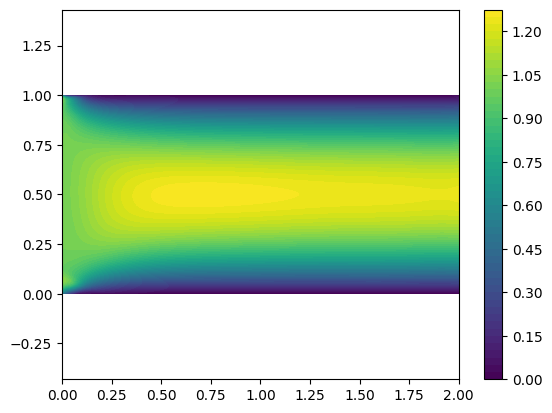

In [144]:
# contour plot
with torch.no_grad():
    output = stokes_nn(x_y)
    U_pred = output[:,0:1].detach().numpy().reshape(dimension,dimension)
    V_pred = output[:,1:2].detach().numpy().reshape(dimension,dimension)
    P_pred = output[:,2:3].detach().numpy().reshape(dimension,dimension)
vel_mag = np.sqrt(U_pred**2 + V_pred**2)
x_plot = x_y[:,0].detach().numpy().reshape(dimension,dimension)
y_plot = x_y[:,1].detach().numpy().reshape(dimension,dimension)
plt.contourf(x_plot,y_plot,vel_mag,50)
plt.colorbar()
plt.axis('equal')

(np.float64(-0.1), np.float64(2.1), np.float64(-0.05), np.float64(1.05))

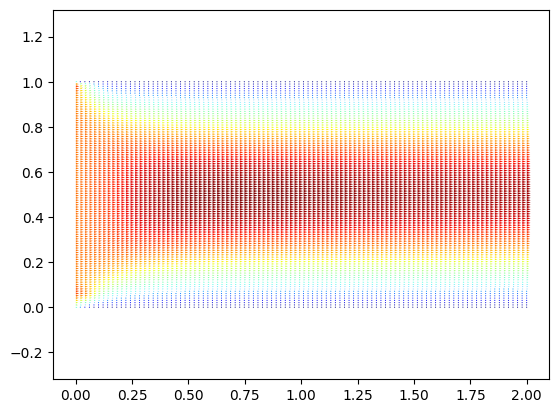

In [145]:
#quiver plot
plt.quiver(x_plot,y_plot,U_pred,V_pred,vel_mag,cmap = 'jet')
plt.axis('equal')

In [146]:
tensor = torch.tensor([[1.95,0.5]])
out = stokes_nn(tensor)
U_center_pred = out[0,0].item()
U_analytical = 1.5
acc = (U_analytical-U_center_pred)/U_analytical
print(f'The Predicted centerline velocity at flow exit for developed flow is {100 - acc*100}% Accurate')

The Predicted centerline velocity at flow exit for developed flow is 81.91990852355957% Accurate
